Before you begin
Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine by launching a command window and running:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archiveLinks to an external site. and save it to your working directory (the same directory that has your notebook).
The task
Follow the tutorial found at https://sep.readthedocs.io/en/stable/tutorial.htmlLinks to an external site., applying it to the data file you just downloaded. For best results (and for full credit) follow these suggestions: 

Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
Use markdown to break the notebook into sections, as in the tutorial.
Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

In [19]:
import astropy
import sep
print("Both installed successfully")

Both installed successfully


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import sep

In [21]:
filename = "hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits"

with fits.open(filename) as hdul:
    hdul.info()
    data = hdul[0].data
    header = hdul[0].header

print("Shape:", data.shape)
print("Data type:", data.dtype)

Filename: hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (3600, 3600)   float32   
Shape: (3600, 3600)
Data type: >f4


In [22]:
data = data.astype(data.dtype.newbyteorder('='))
print(data.dtype)

float32


In [23]:
bkg = sep.Background(data)

print("Global background:", bkg.globalback)
print("Global background RMS:", bkg.globalrms)

Global background: 0.0
Global background RMS: 0.0005398219218477607


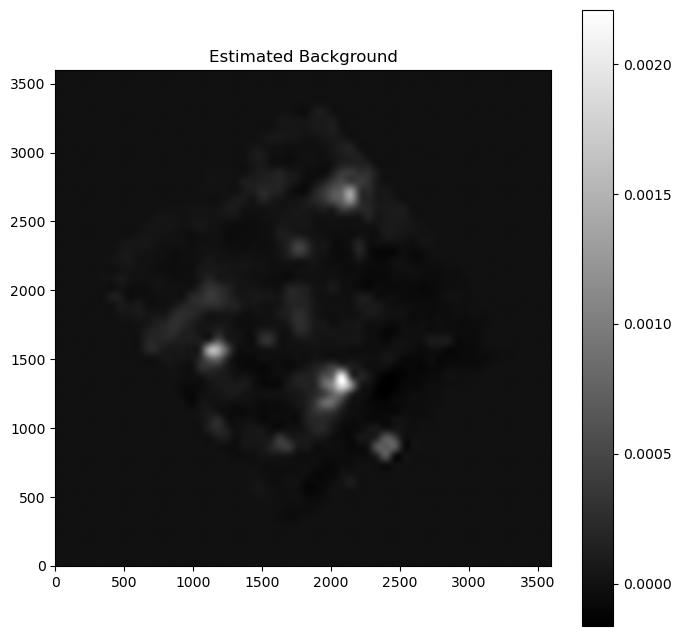

In [24]:
plt.figure(figsize=(8, 8))
plt.imshow(bkg.back(), cmap='gray', origin='lower')
plt.colorbar()
plt.title("Estimated Background")
plt.show()

In [25]:
data_sub = data - bkg

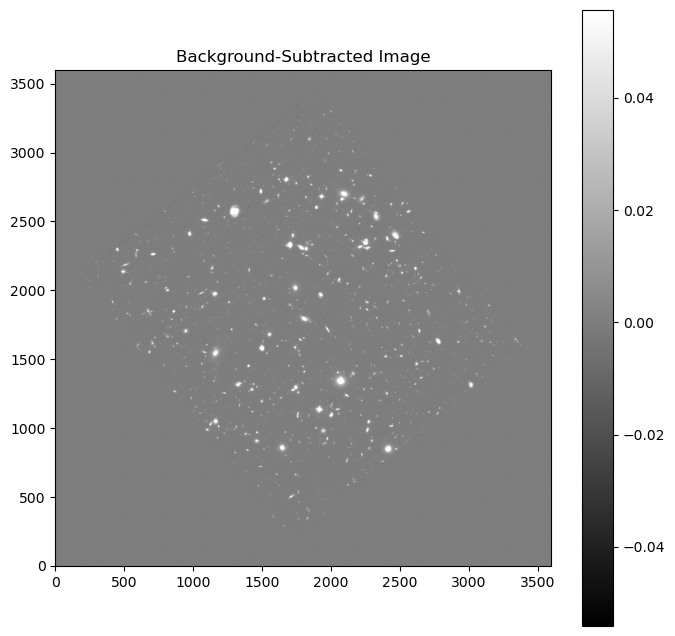

In [26]:
plt.figure(figsize=(8, 8))
mean = np.mean(data_sub)
std = np.std(data_sub)

plt.imshow(data_sub, cmap='gray', origin='lower', vmin=mean-std, vmax=mean+std)
plt.colorbar()
plt.title("Background-Subtracted Image")
plt.show()

In [27]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)
print("Number of sources detected:", len(objects))

Number of sources detected: 8641


In [28]:
objects[:5]

array([(0.00080973, 17, 14, 1735, 1740, 245, 248, 1737.8231612 , 246.82888027, 2.68922691, 0.60197393, -0.0272194 , 0.01844161, 0.00540655, -0.00020499, 1.6399945 , 0.77564102, -0.01303782, 0.37202436, 1.66196215,  0.03364359, 0.02728598, 0.03645862, 0.00300929, 0.00615413, 1739, 247, 1739, 247, 0),
       (0.00080973, 18, 17, 1741, 1746, 246, 251, 1743.38088137, 249.25744868, 1.93635164, 2.18910645, -1.5405129 , 0.01069696, 0.01217194, -0.00867668, 1.89958334, 0.71905571, -0.82632446, 1.1733433 , 1.03786874,  1.65140486, 0.03431803, 0.04817118, 0.00361211, 0.00546959, 1743, 250, 1742, 250, 0),
       (0.00080973,  5,  5, 1765, 1767, 252, 253, 1765.69754404, 252.50539983, 0.45881798, 0.24997084, -0.12002504, 0.0158041 , 0.00695631, -0.00362343, 0.71657974, 0.44193023, -0.42739838, 2.49260187, 4.57513571,  2.39367628, 0.00725233, 0.01450479, 0.00197906, 0.00377289, 1765, 253, 1765, 253, 0),
       (0.00080973,  6,  5, 1684, 1686, 253, 255, 1684.8689451 , 253.88453767, 0.43526222, 0.4219

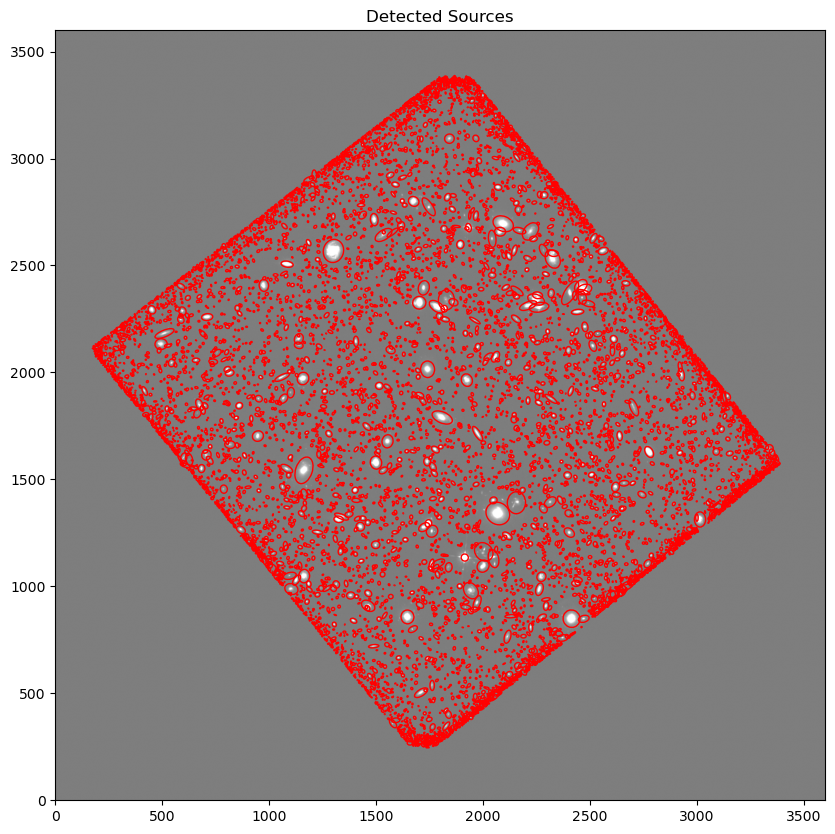

In [29]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 10))
mean = np.mean(data_sub)
std = np.std(data_sub)

ax.imshow(data_sub, cmap='gray', origin='lower', vmin=mean-std, vmax=mean+std)

for obj in objects:
    e = Ellipse(
        xy=(obj['x'], obj['y']),
        width=6*obj['a'],
        height=6*obj['b'],
        angle=obj['theta'] * 180.0 / np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.title("Detected Sources")
plt.show()

In [30]:
x = objects['x']
y = objects['y']

flux, fluxerr, flag = sep.sum_circle(data_sub, x, y, 3.0, err=bkg.globalrms)
print("Measured fluxes for", len(flux), "sources")

Measured fluxes for 8641 sources


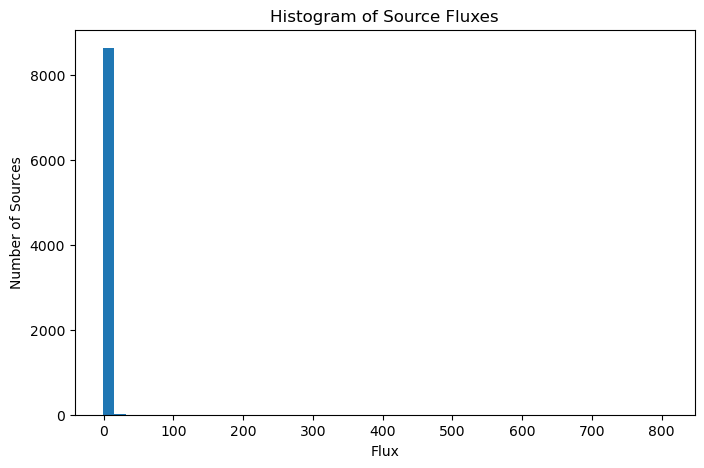

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(flux, bins=50)
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Histogram of Source Fluxes")
plt.show()

In [32]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation of flux:", std_flux)

Mean flux: 0.36181040728805286
Median flux: 0.030961835534690188
Standard deviation of flux: 9.242994159843427


In [33]:
z_scores = (flux - mean_flux) / std_flux
largest_outlier_index = np.argmax(np.abs(z_scores))

largest_outlier_flux = flux[largest_outlier_index]
largest_outlier_z = z_scores[largest_outlier_index]

print("Largest outlier flux:", largest_outlier_flux)
print("Number of standard deviations from the mean:", abs(largest_outlier_z))

Largest outlier flux: 807.2972835731507
Number of standard deviations from the mean: 87.30238916212102


Final Answer
1. I found that there were 8640 sources in the image. I used SEP to detect the sources and measured their fluxes using circular aperture photometry.
2. Mean = 0.362, Median = 0.096, SD = 9.244
3. Largest outlier = 807.297, which is 97.297 SD from the mean.